# NYC Airbnb Room Type Classification

**Dataset:** [New York City Airbnb Open Data](https://www.kaggle.com/datasets/dgomonov/new-york-city-airbnb-open-data) (Kaggle)

**Goal:** Predict the `room_type` of an Airbnb listing (`Entire home/apt`, `Private room`, or `Shared room`)
using listing attributes such as price, location, availability, and review activity.

**What this notebook covers (the full ML lifecycle):**

1. Problem framing & data loading
2. Exploratory Data Analysis (EDA) — univariate, bivariate, skewness, outliers
3. Data cleaning & feature engineering
4. Train / test split
5. Preprocessing with `ColumnTransformer` + `Pipeline`
6. Baseline model
7. Multiple candidate algorithms (Logistic Regression, Decision Tree, Random Forest, Gradient Boosting)
8. Model comparison (cross-validation)
9. Hyperparameter tuning of the best model
10. Final evaluation on the untouched test set
11. Feature importance
12. Saving the final pipeline (model artifact)
13. Conclusion & next steps



#1. import library

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#2. load dataset

In [ ]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("dgomonov/new-york-city-airbnb-open-data")

print("Path to dataset files:", path)

df=pd.read_csv(os.path.join(path, 'AB_NYC_2019.csv'))

Using Colab cache for faster access to the 'new-york-city-airbnb-open-data' dataset.
Path to dataset files: /kaggle/input/new-york-city-airbnb-open-data


In [ ]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [ ]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [ ]:
df.shape

(48895, 16)

#3. EDA
We explore the data in the standard order every ML engineer follows:

- Missing values
- Univariate analysis (one variable at a time — distributions, skewness)
- Bivariate analysis (relationship between features and the target)
- Correlation between numeric features
- Outlier inspection


3.1 Missing Values

In [ ]:
missing=df.isnull().sum()
missing[missing>0]

,0
name,16
host_name,21
last_review,10052
reviews_per_month,10052


3.2 Target Variable -- room_type

In [ ]:
df.room_type.unique()

array(['Private room', 'Entire home/apt', 'Shared room'], dtype=object)

<Axes: xlabel='room_type', ylabel='count'>

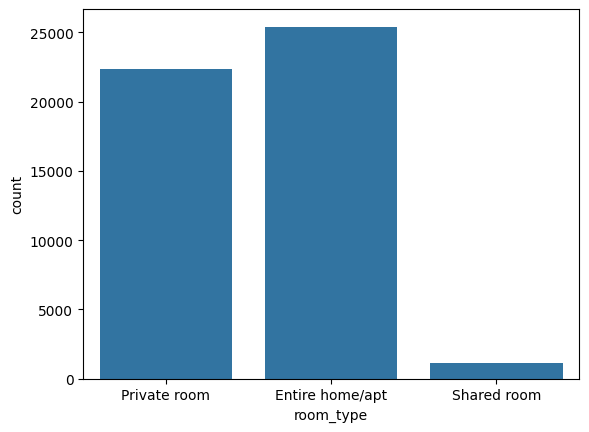

In [ ]:
sns.countplot(x=df.room_type)

the classes are imbalanced -> Shared Room is a Small Minority.

3.3 Univariate Analysis --Numeric Features

In [ ]:
numerical_cols=df.select_dtypes(include=['int64','float64']).columns

In [ ]:
numerical_cols

Index(['id', 'host_id', 'latitude', 'longitude', 'price', 'minimum_nights',
       'number_of_reviews', 'reviews_per_month',
       'calculated_host_listings_count', 'availability_365'],
      dtype='object')

In [ ]:
numerical_cols=numerical_cols.drop(['id','host_id'])

array([[<Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'price'}>],
       [<Axes: title={'center': 'minimum_nights'}>,
        <Axes: title={'center': 'number_of_reviews'}>,
        <Axes: title={'center': 'reviews_per_month'}>],
       [<Axes: title={'center': 'calculated_host_listings_count'}>,
        <Axes: title={'center': 'availability_365'}>, <Axes: >]],
      dtype=object)

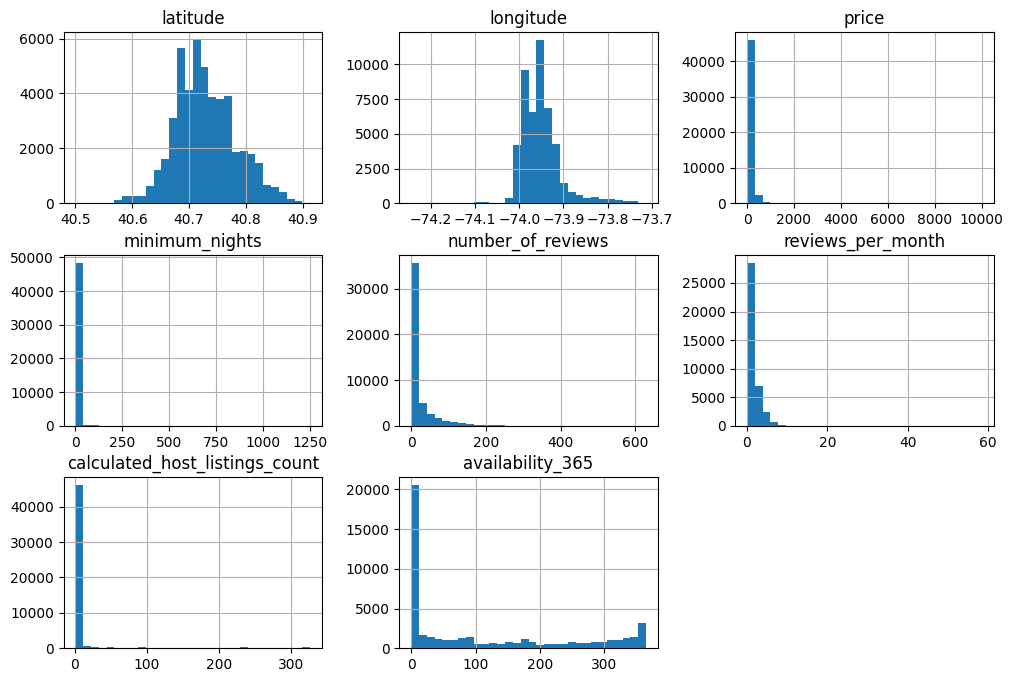

In [ ]:
df[numerical_cols].hist(bins=30, figsize=(12,8))

3.4 Univariate Analysis -- Categorical

<Axes: xlabel='neighbourhood_group', ylabel='count'>

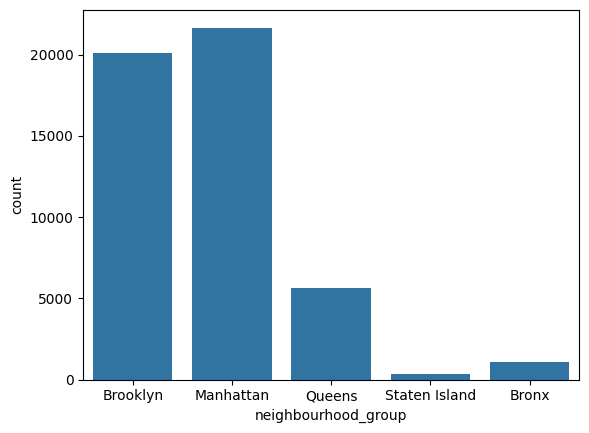

In [ ]:
sns.countplot(x=df.neighbourhood_group)

3.5 Bivariate Analysis- features vs target

<Axes: xlabel='room_type', ylabel='price'>

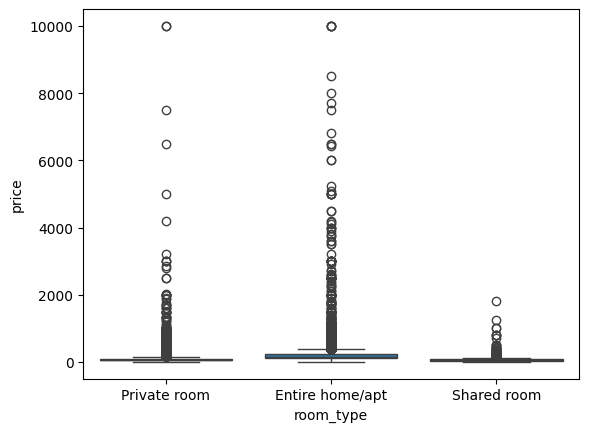

In [ ]:
sns.boxplot(x='room_type', y='price', data=df)

<Axes: xlabel='room_type', ylabel='number_of_reviews'>

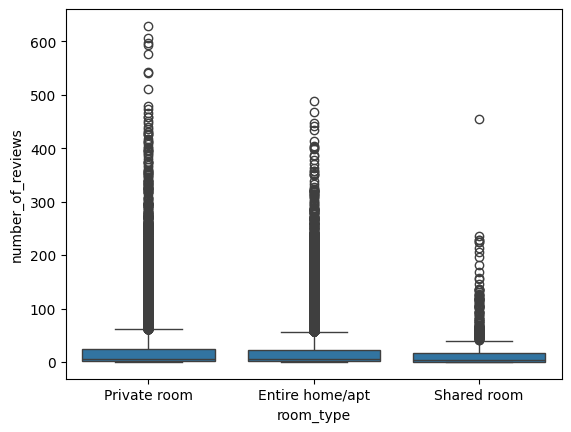

In [ ]:
sns.boxplot(x='room_type', y='number_of_reviews', data=df)

3.6 Correlation B/W num cols

<Axes: >

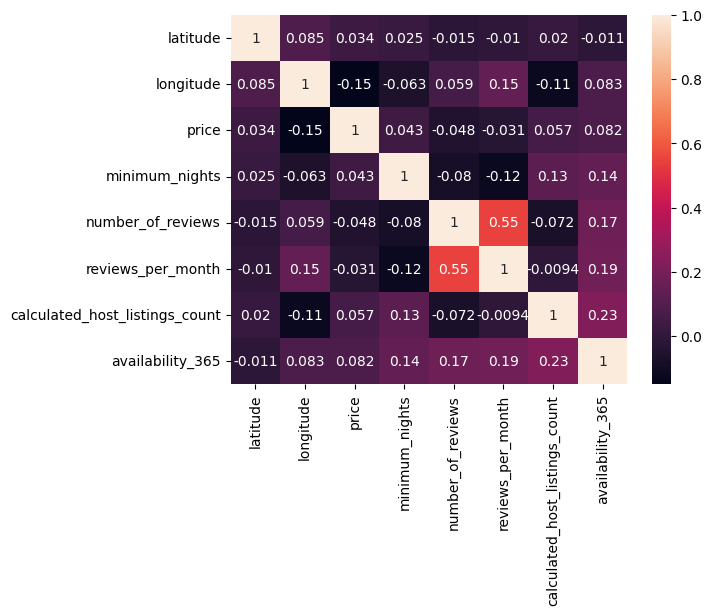

In [ ]:
corr=df[numerical_cols].corr()
#print(corr)
sns.heatmap(corr, annot=True)

3.7 Geographic Distribution

<Axes: xlabel='longitude', ylabel='latitude'>

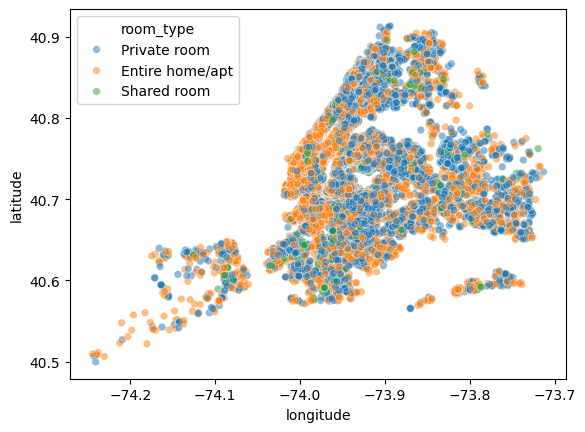

In [ ]:
sns.scatterplot(x='longitude', y='latitude', hue='room_type', data=df, alpha=0.5,s=30)

#4. Data Cleaning & FE
Steps:
1. Drop columns that are pure identifiers or free text and carry no generalizable signal for a
   tabular model (`id`, `name`, `host_id`, `host_name`, `last_review`).
2. Fill missing `reviews_per_month` with `0` (no reviews yet).
3. Cap extreme outliers in `price` and `minimum_nights` using percentile clipping, so a handful of
   data-entry errors (e.g. $10,000/night, 1,250 minimum nights) don't distort the model.
4. Separate features (`X`) from the target (`y`).

In [ ]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

In [ ]:
df1=df.drop(columns=['id', 'name', 'host_id', 'host_name', 'last_review'], axis=1)

In [ ]:
df1.head()

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,1,365
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0


In [ ]:
#no reviews yet -> 0 reviews per month, not missing
df1['reviews_per_month']=df1['reviews_per_month'].fillna(0)

In [ ]:
#cap Extreme outilers instead of deleting rows

price_cap= df1['price'].quantile(0.99)
night_cap=df1['minimum_nights'].quantile(0.99)

df1['price']=df1['price'].clip(upper=price_cap)
df1['minimum_nights']=df1['minimum_nights'].clip(upper=night_cap)

In [ ]:
df1.head()

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,0.00,1,365
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0


In [ ]:
X=df1.drop(columns=['room_type'])
y=df1['room_type']

#Train Test Split

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42,stratify=y)

#6. Preprocessing : ColumnTransformer + Pipeline

Production ML code should never manually transform train/test data with separate lines — it's
error-prone and leaks information. Instead we build a single, reusable `ColumnTransformer`:

- **Numeric features** → median imputation + handle skewness + standard scaling
- **Categorical features** → most-frequent imputation + one-hot encoding

This transformer will be the first step of *every* model pipeline below, so preprocessing is
learned only on training data and applied consistently everywhere (no data leakage)

In [ ]:
df1[numerical_cols].skew()

,0
latitude,0.237167
longitude,1.284210
price,2.776321
minimum_nights,2.360347
number_of_reviews,3.690635
reviews_per_month,3.300723
calculated_host_listings_count,7.933174
availability_365,0.763408


In [ ]:
numerical_cols

categorical_cols=['neighbourhood_group', 'neighbourhood']

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,PowerTransformer, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer


In [ ]:
numerical_cols

categorical_cols=['neighbourhood_group', 'neighbourhood']

In [ ]:
#pipeline-> num cols

numerical_pipeline=Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    # ('skewness', PowerTransformer(method='yeo-johnson')),
    ('scaler', StandardScaler())
])

#pipeline-> Cat cols

categorical_pipeline=Pipeline(steps=[
('imputer', SimpleImputer(strategy='most_frequent')),
('encode', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor=ColumnTransformer(transformers=[
('num', numerical_pipeline, numerical_cols),
('cat', categorical_pipeline, categorical_cols)
])

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 Index(['latitude', 'longitude', 'price', 'minimum_nights', 'number_of_reviews',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encode',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['neighbourhood_group', 'neighbourhood'])])

#8. Try multiple algo

We now compare several models, each wrapped in its own pipeline with the **same** preprocessor. We
evaluate each with 3-fold **stratified cross-validation** on the training set (never touching the
test set yet), so the comparison is fair and robust.

Models tried:
1. Logistic Regression — simple, interpretable linear baseline
2. Decision Tree — a single non-linear model, prone to overfitting
3. Random Forest — an ensemble of trees, usually a strong general-purpose model
4. Gradient Boosting — sequential ensemble, often the most accurate of the classics

**SMOTE(Synthethic Minority Oversampling)** for class Imbalance
--------------------
1. high chance of overfitting
2. data leakage
--------------------
to avoid this we will use class_weight attribute


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

In [ ]:
models={
    'lr': LogisticRegression(class_weight='balanced', random_state=42),
    'df' : DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'rf' : RandomForestClassifier(class_weight='balanced', random_state=42),
    'gb' : GradientBoostingClassifier( random_state=42)
}
#class weight='balanced i.e. tells the model to pay more attention to minority class but the problem is GradientBoosting doesn't support it.

for name, model in models.items():
  Pipe=Pipeline(steps=[
      ('preprocessor', preprocessor), ('classifier', model)])

  accuracy=cross_val_score(Pipe, X_train, y_train, cv=3, scoring='accuracy')
  macrof1 = cross_val_score(Pipe, X_train,y_train, cv=3, scoring='f1_macro')

  print(f"{name} -> Accuracy: {accuracy.mean():.3f} F1: {macrof1.mean():.3f}")

lr -> Accuracy: 0.658 F1: 0.522
df -> Accuracy: 0.787 F1: 0.652
rf -> Accuracy: 0.852 F1: 0.714
gb -> Accuracy: 0.849 F1: 0.705


## 9. Hyperparameter Tuning

We pick the best-performing model from the comparison above (whichever one that turns out to be) and
search over *its* key hyperparameters using `RandomizedSearchCV` (cheaper than an exhaustive grid
search, while still exploring the space well). We keep optimizing for **macro-F1** since the classes
are imbalanced.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

best_pipeline=Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42))]
)

param_distribution = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [8,12,15,20,None],
    "classifier__min_samples_split": [2, 5, 10],
}


search= RandomizedSearchCV(estimator=best_pipeline, param_distributions=param_distribution, n_iter=10, cv=3, scoring='f1_macro', random_state=42)

search.fit(X_train,y_train)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               Index(['latitude', 'longitude', 'price', 'minimum_nights', 'number_of_reviews',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype=...
                                                                                               ('encode',
                                                                                                OneHotEncoder(handle_unknown='ignore'))]),
                                                                               ['neighbourhood_group',
                                                                                'neighbourhood'])])),
                                             ('classifier',
                                              RandomForestClassifier(class_weight='balanced',
                                                                     random_state=42))]),
                   param_distributions={'classifier__max_depth': [8, 12, 15, 20,
                                                                  None],
                                        'classifier__min_samples_split': [2, 5,
                                                                          10],
                                        'classifier__n_estimators': [100, 200,
                                                                     300]},
                   random_state=42, scoring='f1_macro')

In [ ]:
print("best param: ", search.best_params_)
print("best macro f1:", search.best_score_)

best param:  {'classifier__n_estimators': 200, 'classifier__min_samples_split': 10, 'classifier__max_depth': None}
best macro f1: 0.7282871111401406


#10. Final Evaluation on the Test Set



In [ ]:
from sklearn.metrics import confusion_matrix,accuracy_score,f1_score

In [ ]:
best_pipeline=search.best_estimator_
y_pred=best_pipeline.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"F1: {f1_score(y_test, y_pred, average='macro'):.4f}")

Accuracy: 0.857
F1: 0.7452


<Axes: >

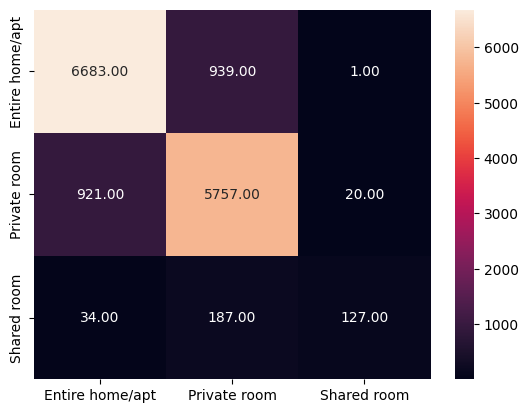

In [ ]:
sns.heatmap(confusion_matrix(y_test,y_pred, ), annot=True, fmt='.2f', xticklabels=best_pipeline.classes_, yticklabels=best_pipeline.classes_)

#11. Saving The Final Model Artifact

In [ ]:
import joblib
joblib.dump(best_pipeline, "Model_Pipeline.pkl", compress=("zlib", 9)) # or compress=9

['Model_Pipeline.pkl']